# 02 — Categorical Plots & Group Comparisons
**Preetham's Seaborn Mastery Series**

Categorical visualizations help analyze data distributions, statistical estimates, and individual observation spreads across categorical groups.

### Notebook Contents:
1. **Categorical Scatter Plots (`sns.stripplot`, `sns.swarmplot`)**
2. **Categorical Distribution Plots (`sns.boxplot`, `sns.violinplot`, `sns.boxenplot`)**
3. **Categorical Estimate Plots (`sns.barplot`, `sns.countplot`, `sns.pointplot`)**
4. **Figure-Level Categorical Faceting (`sns.catplot`)**
5. **Hybrid Overlaid Visualizations (Box + Strip, Violin + Swarm)**
6. **Real-World Case Study: Penguin Species & Titanic Class Analysis**
7. **Summary & Best Practices**


In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

sns.set_theme(style="whitegrid")
%matplotlib inline

# Load Datasets
tips = sns.load_dataset("tips")
penguins = sns.load_dataset("penguins").dropna()
titanic = sns.load_dataset("titanic").dropna(subset=["age", "embarked"])

print("Penguins Dataset Preview:")
print(penguins.head())


Penguins Dataset Preview:
  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
4  Adelie  Torgersen            36.7           19.3              193.0   
5  Adelie  Torgersen            39.3           20.6              190.0   

   body_mass_g     sex  
0       3750.0    Male  
1       3800.0  Female  
2       3250.0  Female  
4       3450.0  Female  
5       3650.0    Male  


## 1. Categorical Scatter Plots (`stripplot` vs `swarmplot`)

- `stripplot()`: Plots all individual data points with optional random jitter along the categorical axis.
- `swarmplot()`: Arranges points so they do not overlap, providing a visual representation of distribution density.


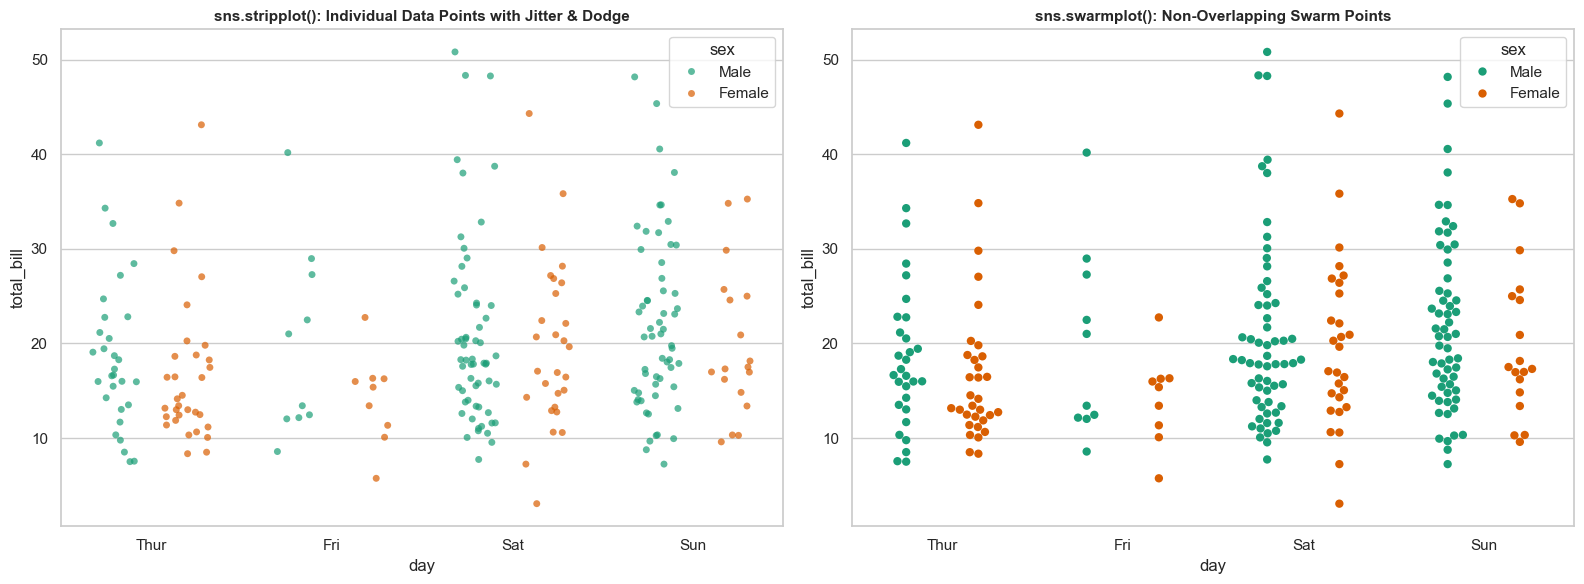

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Stripplot with jitter and dodge
sns.stripplot(
    data=tips,
    x="day",
    y="total_bill",
    hue="sex",
    jitter=0.25,
    dodge=True,
    alpha=0.7,
    palette="Dark2",
    ax=axes[0]
)
axes[0].set_title("sns.stripplot(): Individual Data Points with Jitter & Dodge", fontsize=11, fontweight="bold")

# Swarmplot
sns.swarmplot(
    data=tips,
    x="day",
    y="total_bill",
    hue="sex",
    dodge=True,
    palette="Dark2",
    size=6,
    ax=axes[1]
)
axes[1].set_title("sns.swarmplot(): Non-Overlapping Swarm Points", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()


## 2. Categorical Distribution Plots (`boxplot`, `violinplot`, `boxenplot`)

- `boxplot()`: Summarizes five-number statistics (Min, Q1, Median, Q3, Max) and highlights statistical outliers.
- `violinplot()`: Combines a box plot summary with a kernel density estimation (KDE) curve.
- `boxenplot()`: (Letter-value plot) Designed for large datasets to visualize precise quantile distributions into the tails.


C:\Users\praveen\AppData\Local\Temp\ipykernel_15412\1487662917.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(


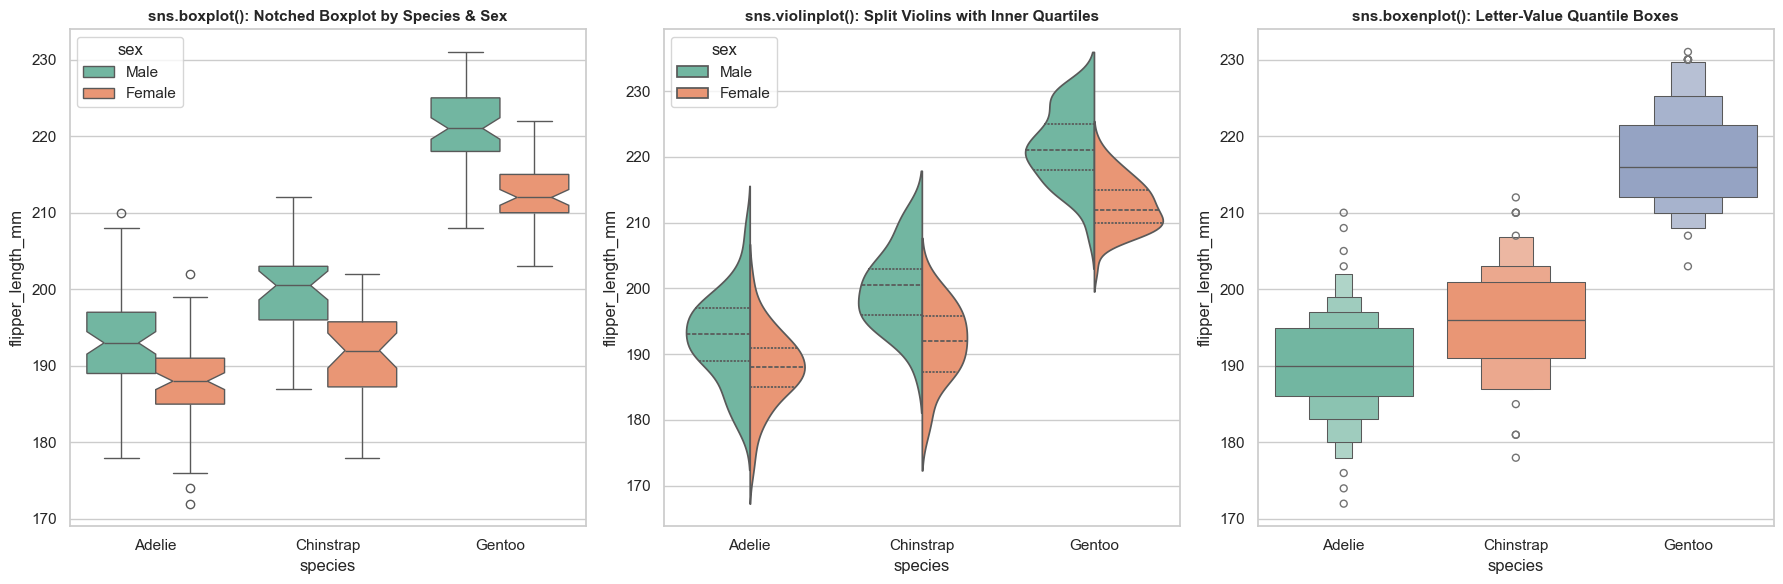

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Boxplot
sns.boxplot(
    data=penguins,
    x="species",
    y="flipper_length_mm",
    hue="sex",
    palette="Set2",
    notch=True,
    ax=axes[0]
)
axes[0].set_title("sns.boxplot(): Notched Boxplot by Species & Sex", fontsize=11, fontweight="bold")

# Split Violin Plot
sns.violinplot(
    data=penguins,
    x="species",
    y="flipper_length_mm",
    hue="sex",
    split=True,
    inner="quartile",
    palette="Set2",
    ax=axes[1]
)
axes[1].set_title("sns.violinplot(): Split Violins with Inner Quartiles", fontsize=11, fontweight="bold")

# Boxenplot
sns.boxenplot(
    data=penguins,
    x="species",
    y="flipper_length_mm",
    palette="Set2",
    ax=axes[2]
)
axes[2].set_title("sns.boxenplot(): Letter-Value Quantile Boxes", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()


## 3. Categorical Estimate Plots (`barplot`, `countplot`, `pointplot`)

- `barplot()`: Computes an aggregate statistic (mean, median) with confidence interval error bars (`errorbar=('ci', 95)` or `errorbar='sd'`).
- `countplot()`: Visualizes frequency counts or proportions for categorical factors.
- `pointplot()`: Shows point estimates and error bars connected by lines to emphasize comparative trends across categories.


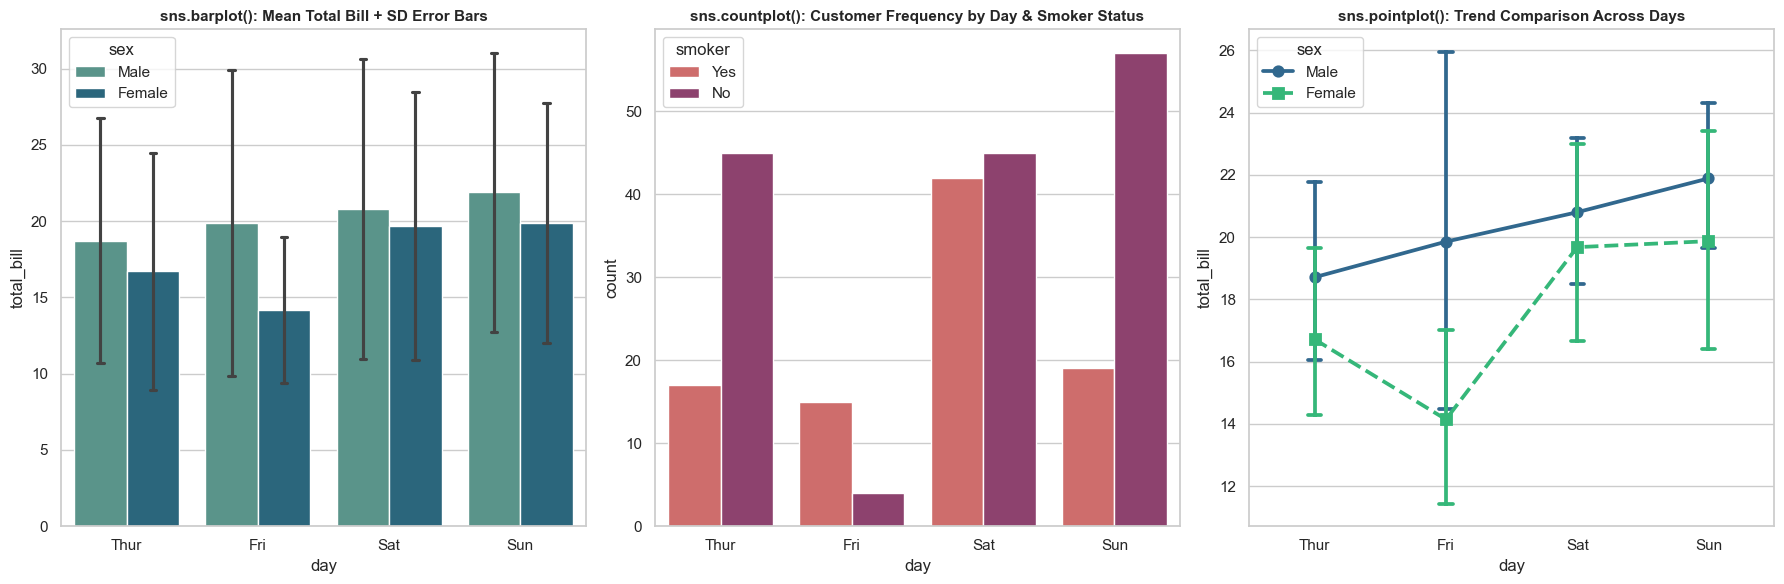

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Barplot with custom mean estimator & error caps
sns.barplot(
    data=tips,
    x="day",
    y="total_bill",
    hue="sex",
    estimator=np.mean,
    errorbar="sd",
    capsize=0.1,
    palette="crest",
    ax=axes[0]
)
axes[0].set_title("sns.barplot(): Mean Total Bill + SD Error Bars", fontsize=11, fontweight="bold")

# Countplot with percentage display / hue ordering
sns.countplot(
    data=tips,
    x="day",
    hue="smoker",
    order=["Thur", "Fri", "Sat", "Sun"],
    palette="flare",
    ax=axes[1]
)
axes[1].set_title("sns.countplot(): Customer Frequency by Day & Smoker Status", fontsize=11, fontweight="bold")

# Pointplot for mean trend comparisons
sns.pointplot(
    data=tips,
    x="day",
    y="total_bill",
    hue="sex",
    markers=["o", "s"],
    linestyles=["-", "--"],
    capsize=0.1,
    palette="viridis",
    ax=axes[2]
)
axes[2].set_title("sns.pointplot(): Trend Comparison Across Days", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()


## 4. Figure-Level Categorical Plot (`sns.catplot`)

`catplot()` provides unified access to all 8 categorical plot types (`strip`, `swarm`, `box`, `violin`, `boxen`, `bar`, `count`, `point`) with multi-column faceting.


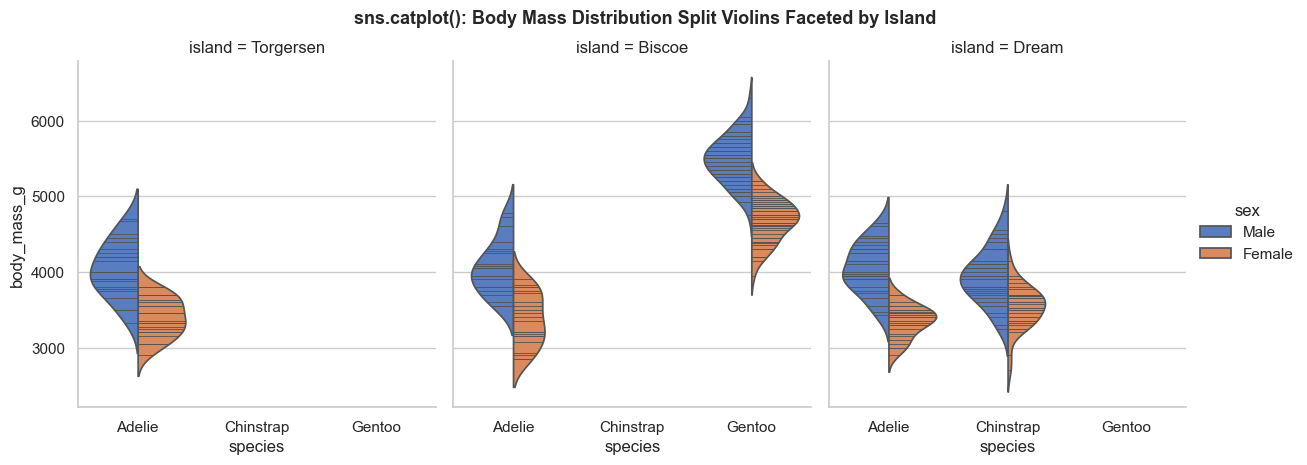

In [5]:
# Figure-Level Categorical Facet Grid
g = sns.catplot(
    data=penguins,
    x="species",
    y="body_mass_g",
    hue="sex",
    col="island",
    kind="violin",
    split=True,
    inner="stick",
    height=4.5,
    aspect=0.9,
    palette="muted"
)
g.fig.suptitle("sns.catplot(): Body Mass Distribution Split Violins Faceted by Island", y=1.03, fontsize=13, fontweight="bold")
plt.show()


## 5. Overlaid Hybrid Visualizations (Box + Strip & Violin + Swarm)

Overlaying individual observation points on top of distribution summary boxes/violins gives stakeholders full clarity into summary statistics AND underlying raw data points.


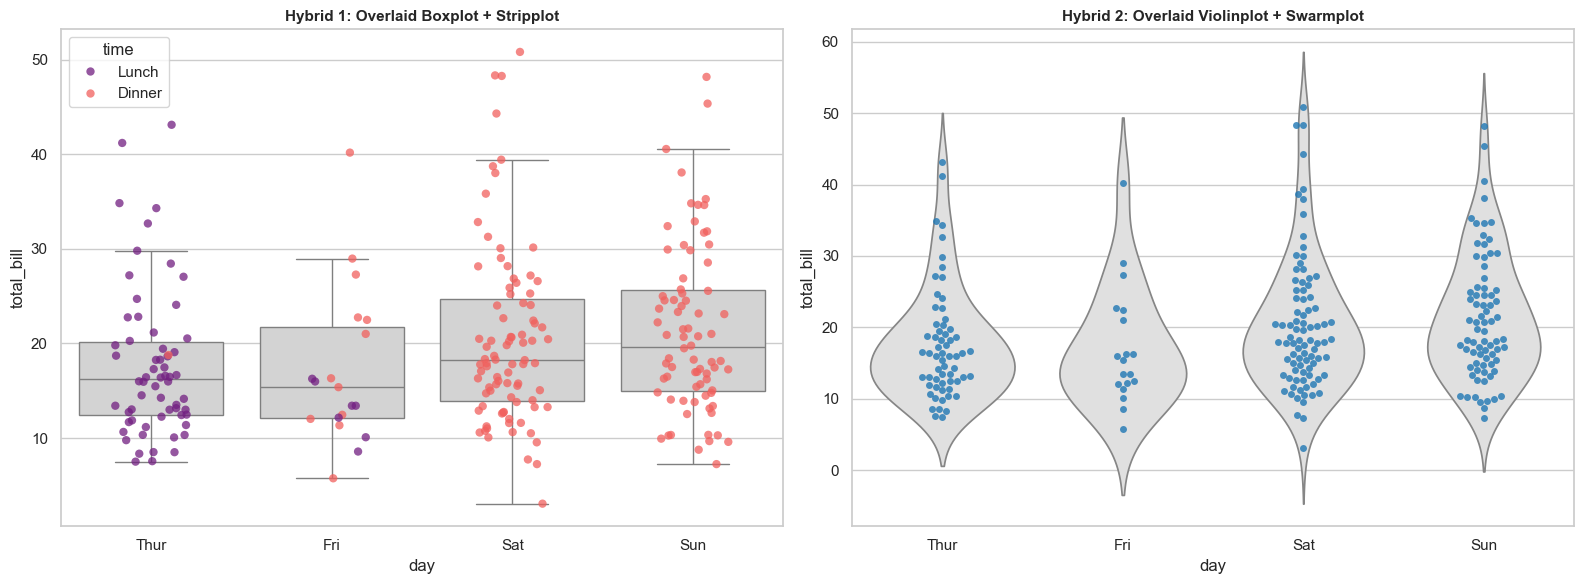

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Hybrid 1: Boxplot + Stripplot
sns.boxplot(
    data=tips,
    x="day",
    y="total_bill",
    color="lightgray",
    fliersize=0,
    ax=axes[0]
)
sns.stripplot(
    data=tips,
    x="day",
    y="total_bill",
    hue="time",
    jitter=0.2,
    size=6,
    palette="magma",
    alpha=0.75,
    ax=axes[0]
)
axes[0].set_title("Hybrid 1: Overlaid Boxplot + Stripplot", fontsize=11, fontweight="bold")

# Hybrid 2: Violinplot + Swarmplot
sns.violinplot(
    data=tips,
    x="day",
    y="total_bill",
    inner=None,
    color="#e0e0e0",
    ax=axes[1]
)
sns.swarmplot(
    data=tips,
    x="day",
    y="total_bill",
    color="#1f77b4",
    size=5,
    alpha=0.8,
    ax=axes[1]
)
axes[1].set_title("Hybrid 2: Overlaid Violinplot + Swarmplot", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()


## 6. Real-World Case Study: Titanic Categorical Analysis

Let's examine how passenger class, sex, and embarkation port interact to determine survival rates on the Titanic.


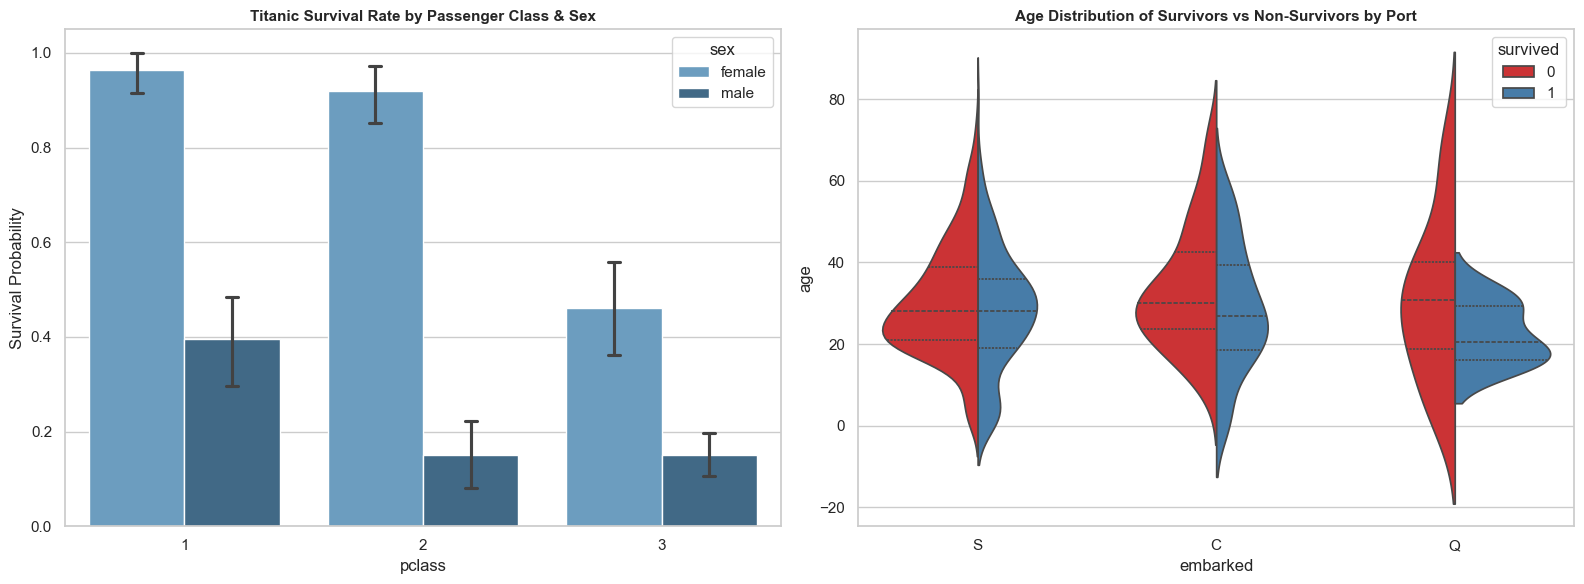

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Survival rate by Class and Sex
sns.barplot(
    data=titanic,
    x="pclass",
    y="survived",
    hue="sex",
    palette="Blues_d",
    capsize=0.1,
    ax=axes[0]
)
axes[0].set_title("Titanic Survival Rate by Passenger Class & Sex", fontsize=11, fontweight="bold")
axes[0].set_ylabel("Survival Probability")

# Age distribution by Survival & Embarked Port
sns.violinplot(
    data=titanic,
    x="embarked",
    y="age",
    hue="survived",
    split=True,
    inner="quartile",
    palette="Set1",
    ax=axes[1]
)
axes[1].set_title("Age Distribution of Survivors vs Non-Survivors by Port", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()


## 7. Summary & Best Practices

- Use `stripplot` / `swarmplot` for smaller datasets ($N < 500$) to show true raw observations.
- Use `boxplot` or `violinplot` for medium datasets to compare medians, interquartile ranges, and multimodal distributions.
- Use `boxenplot` for large datasets ($N > 1000$) where tail quantiles are important.
- Always add `errorbar` options on `barplot` to communicate statistical uncertainty.
- Leverage `catplot()` for multi-categorical faceting.
